# Análise do Mercado Automotivo Brasileiro
## Emplacamentos, rankings e avanço dos veículos eletrificados

**Período:** julho de 2025 a junho de 2026  
**Fonte:** informativos mensais da FENABRAVE

### Objetivo

Analisar a evolução dos emplacamentos de automóveis no Brasil, identificando:

- principais marcas e modelos presentes no Top 50 mensal;
- mudanças de posição e consistência no ranking;
- modelos que ganharam ou perderam força;
- evolução dos veículos híbridos e 100% elétricos;
- crescimento da participação dos eletrificados no mercado de automóveis.

### Escopo e limitações

A base de modelos contém os **50 automóveis mais emplacados em cada mês**.
Portanto, somas e participações calculadas a partir dessa base descrevem a
**amostra Top 50**, e não o mercado completo por marca.

Para a análise de eletrificação, a participação foi calculada em relação ao
**total de automóveis emplacados** informado nos relatórios da FENABRAVE.


## 1. Bibliotecas

Nesta etapa são importadas as bibliotecas usadas para manipulação dos dados,
cálculos e visualizações.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## 2. Carregamento dos dados

Foram utilizadas duas bases construídas a partir dos informativos mensais da
FENABRAVE: uma com os **50 modelos de automóveis mais emplacados por mês** e
outra com os totais mensais de **híbridos e elétricos**.


In [2]:
# Carregamento das bases
# Estrutura esperada no repositório:
# projeto/
# ├── AnaliseMercadoAutomotivo_GitHub.ipynb
# └── dados/
#     ├── automoveis_fenabrave_jul2025_jun2026.csv
#     └── eletrificados_fenabrave_jul2025_jun2026.csv

dados_automoveis = pd.read_csv(
    "dados/automoveis_fenabrave_jul2025_jun2026.csv"
)

dados_eletrificados = pd.read_csv(
    "dados/eletrificados_fenabrave_jul2025_jun2026.csv"
)


## 3. Exploração e validação inicial

Antes da análise, são verificadas a cobertura temporal, estatísticas descritivas,
tipos de dados e possíveis inconsistências.


In [3]:
dados_automoveis['periodo'].unique()
dados_automoveis.groupby('periodo').size()

,0
periodo,
2025-07,50
2025-08,50
2025-09,50
2025-10,50
2025-11,50
2025-12,50
2026-01,50
2026-02,50
2026-03,50


In [4]:
dados_automoveis.describe()

,ano,mes_numero,posicao,emplacamentos
count,600.000000,600.000000,600.00000,600.000000
mean,2025.500000,6.500000,25.50000,3420.973333
std,0.500417,3.454933,14.44291,2582.704613
min,2025.000000,1.000000,1.00000,429.000000
25%,2025.000000,3.750000,13.00000,1270.500000
50%,2025.500000,6.500000,25.50000,2848.500000
75%,2026.000000,9.250000,38.00000,4945.000000
max,2026.000000,12.000000,50.00000,12940.000000


In [5]:
dados_automoveis['emplacamentos'].describe()

,emplacamentos
count,600.000000
mean,3420.973333
std,2582.704613
min,429.000000
25%,1270.500000
50%,2848.500000
75%,4945.000000
max,12940.000000


## 4. Tratamento dos dados

É criada uma cópia das bases originais, os textos de marca e modelo são
padronizados e o período é convertido para uma coluna de data.


In [6]:
dados_automoveis_tratados=dados_automoveis.copy()
dados_eletrificados_tratados=dados_eletrificados.copy()

In [7]:
dados_automoveis_tratados['marca'] = (
    dados_automoveis_tratados['marca'].str.strip().str.upper()
)

dados_automoveis_tratados['modelo'] = (
    dados_automoveis_tratados['modelo'].str.strip().str.upper()
)


In [8]:
dados_automoveis_tratados['data']=pd.to_datetime(dados_automoveis_tratados['periodo']+'-01')
dados_eletrificados_tratados['data']=pd.to_datetime(dados_eletrificados_tratados['periodo']+'-01')


In [9]:
dados_automoveis_tratados[['periodo','data']].head()

,periodo,data
0,2025-07,2025-07-01
1,2025-07,2025-07-01
2,2025-07,2025-07-01
3,2025-07,2025-07-01
4,2025-07,2025-07-01


In [10]:
dados_automoveis_tratados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   periodo        600 non-null    object        
 1   ano            600 non-null    int64         
 2   mes_numero     600 non-null    int64         
 3   mes            600 non-null    object        
 4   posicao        600 non-null    int64         
 5   marca          600 non-null    object        
 6   modelo         600 non-null    object        
 7   emplacamentos  600 non-null    int64         
 8   data           600 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 42.3+ KB


In [11]:
dados_automoveis_tratados['emplacamentos'].min()

429

In [12]:
dados_automoveis_tratados[dados_automoveis_tratados['emplacamentos']<=0]

,periodo,ano,mes_numero,mes,posicao,marca,modelo,emplacamentos,data


In [13]:
(
    dados_automoveis_tratados['posicao'].min(),
    dados_automoveis_tratados['posicao'].max()
)


(<bound method Series.min of 0       1
 1       2
 2       3
 3       4
 4       5
        ..
 595    46
 596    47
 597    48
 598    49
 599    50
 Name: posicao, Length: 600, dtype: int64>,
 50)

In [14]:
dados_automoveis_tratados.groupby('periodo')['posicao'].nunique()

,posicao
periodo,
2025-07,50
2025-08,50
2025-09,50
2025-10,50
2025-11,50
2025-12,50
2026-01,50
2026-02,50
2026-03,50


## 5. Evolução mensal dos modelos presentes no Top 50

> **Importante:** a soma abaixo representa os emplacamentos dos modelos que
> aparecem no Top 50 mensal. Ela não corresponde ao total oficial de automóveis
> emplacados no Brasil.


In [15]:
emplacamento_mes=(
    dados_automoveis_tratados
    .groupby
    (['data','periodo'])['emplacamentos']
    .sum()
    .reset_index()
    .sort_values('data')

)


In [16]:
emplacamento_mes.loc[
    emplacamento_mes['emplacamentos'].idxmax()
]

,5
data,2025-12-01 00:00:00
periodo,2025-12
emplacamentos,196724


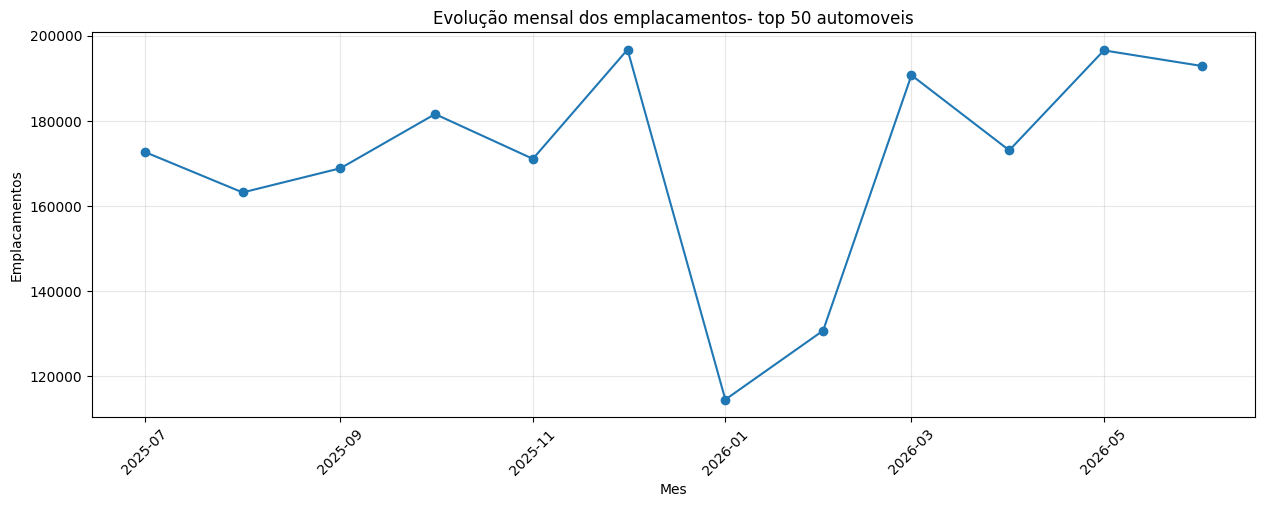

In [17]:
plt.figure(figsize=(15,5))
plt.plot(
    emplacamento_mes['data']
    ,emplacamento_mes['emplacamentos']
    ,marker='o')
plt.title('Evolução mensal dos emplacamentos- top 50 automoveis')
plt.xlabel('Mes')
plt.ylabel('Emplacamentos')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

In [18]:
emplacamento_mes['variacao_pct']=(
    emplacamento_mes['emplacamentos']
    .pct_change()*100
)
emplacamento_mes

,data,periodo,emplacamentos,variacao_pct
0,2025-07-01,2025-07,172679,NaN
1,2025-08-01,2025-08,163180,-5.500958
2,2025-09-01,2025-09,168864,3.483270
3,2025-10-01,2025-10,181581,7.530912
4,2025-11-01,2025-11,171068,-5.789703
5,2025-12-01,2025-12,196724,14.997545
6,2026-01-01,2026-01,114552,-41.770196
7,2026-02-01,2026-02,130742,14.133319
8,2026-03-01,2026-03,190712,45.868963
9,2026-04-01,2026-04,173068,-9.251646


In [19]:
emplacamento_mes['variacao_pct']=emplacamento_mes['variacao_pct'].round(2)


In [20]:
emplacamento_mes[
    ['periodo','emplacamentos','variacao_pct']
    ]

,periodo,emplacamentos,variacao_pct
0,2025-07,172679,NaN
1,2025-08,163180,-5.50
2,2025-09,168864,3.48
3,2025-10,181581,7.53
4,2025-11,171068,-5.79
5,2025-12,196724,15.00
6,2026-01,114552,-41.77
7,2026-02,130742,14.13
8,2026-03,190712,45.87
9,2026-04,173068,-9.25


In [21]:
primeiro_valor=emplacamento_mes.iloc[0]['emplacamentos']
ultimo_valor=emplacamento_mes.iloc[-1]['emplacamentos']

crescimento_periodo=((ultimo_valor-primeiro_valor)
/primeiro_valor)*100

print(f"Variação entre o primeiro e o ultimo mes é de {crescimento_periodo:.2f}%")

Variação entre o primeiro e o ultimo mes é de 11.70%


## 6. Análise por marca

Nesta seção são avaliados volume acumulado, quantidade de modelos presentes no
ranking e evolução mensal das principais marcas.

> A participação calculada nesta seção é a participação **dentro da amostra
> Top 50**, e não o market share oficial da marca no mercado total.


In [22]:
ranking_marca=(
    dados_automoveis_tratados
    .groupby('marca')['emplacamentos']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
ranking_marca

,marca,emplacamentos
0,VW,407206
1,FIAT,308961
2,GM,233477
3,HYUNDAI,210617
4,BYD,155306
5,JEEP,124752
6,TOYOTA,107160
7,RENAULT,104481
8,HONDA,103901
9,CAOA CHERY,77608


In [23]:
top10_marca=ranking_marca.head(10)
top10_marca

,marca,emplacamentos
0,VW,407206
1,FIAT,308961
2,GM,233477
3,HYUNDAI,210617
4,BYD,155306
5,JEEP,124752
6,TOYOTA,107160
7,RENAULT,104481
8,HONDA,103901
9,CAOA CHERY,77608


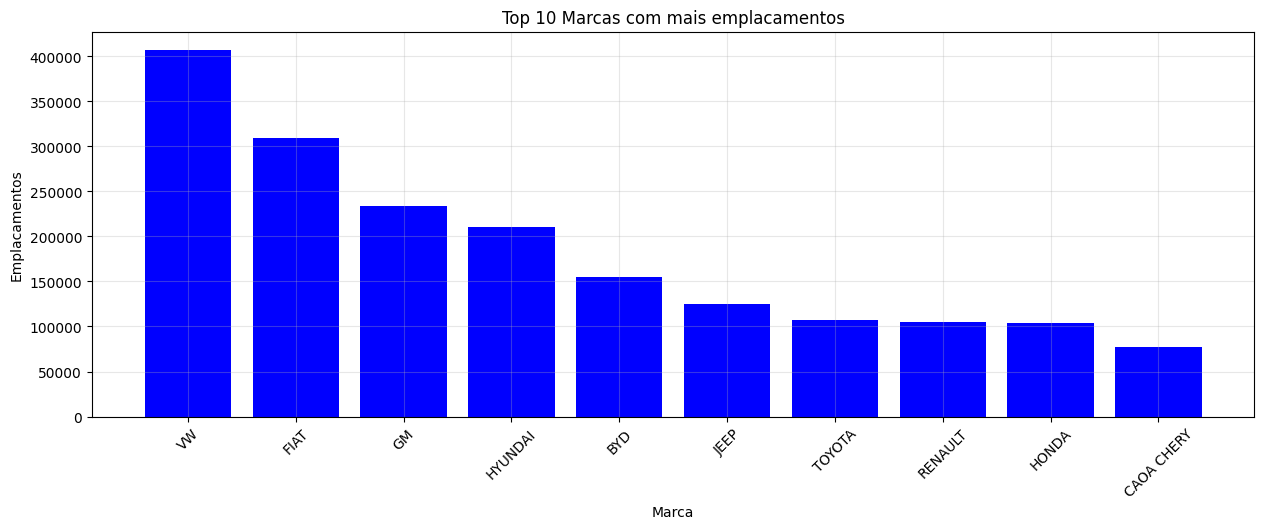

In [24]:
plt.figure(figsize=(15,5))
plt.bar(
    top10_marca['marca']
    ,top10_marca['emplacamentos']
    ,color='blue'
)
plt.title('Top 10 Marcas com mais emplacamentos')
plt.xlabel('Marca')
plt.ylabel('Emplacamentos')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


In [25]:
total_emplacamentos=dados_automoveis_tratados['emplacamentos'].sum()
total_emplacamentos

np.int64(2052584)

In [26]:
ranking_marca['participacao_pct']=(
    ranking_marca['emplacamentos']/total_emplacamentos*100
)
ranking_marca['participacao_pct']=(ranking_marca['participacao_pct'].round(2))
ranking_marca.head(10)

,marca,emplacamentos,participacao_pct
0,VW,407206,19.84
1,FIAT,308961,15.05
2,GM,233477,11.37
3,HYUNDAI,210617,10.26
4,BYD,155306,7.57
5,JEEP,124752,6.08
6,TOYOTA,107160,5.22
7,RENAULT,104481,5.09
8,HONDA,103901,5.06
9,CAOA CHERY,77608,3.78


In [27]:
modelos_por_marca=(
    dados_automoveis_tratados
    .groupby('marca')['modelo']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="quantidade_modelos")
)
modelos_por_marca
#

,marca,quantidade_modelos
0,VW,7
1,GM,6
2,BYD,5
3,FIAT,5
4,RENAULT,4
5,TOYOTA,4
6,HONDA,4
7,NISSAN,4
8,CAOA CHERY,3
9,JEEP,3


In [28]:
ranking_marca_completo=ranking_marca.merge(
    modelos_por_marca,on='marca'

)
ranking_marca_completo.head(10)

,marca,emplacamentos,participacao_pct,quantidade_modelos
0,VW,407206,19.84,7
1,FIAT,308961,15.05,5
2,GM,233477,11.37,6
3,HYUNDAI,210617,10.26,3
4,BYD,155306,7.57,5
5,JEEP,124752,6.08,3
6,TOYOTA,107160,5.22,4
7,RENAULT,104481,5.09,4
8,HONDA,103901,5.06,4
9,CAOA CHERY,77608,3.78,3


In [29]:
marca_mes=(
  dados_automoveis_tratados
  .groupby(['data','periodo','marca'])['emplacamentos']
  .sum()
  .reset_index()
  .sort_values('data')
)
marca_mes.head(20)

,data,periodo,marca,emplacamentos
0,2025-07-01,2025-07,BMW,542
17,2025-07-01,2025-07,VW,35728
16,2025-07-01,2025-07,TOYOTA,11536
15,2025-07-01,2025-07,RENAULT,6909
14,2025-07-01,2025-07,PEUGEOT,1809
12,2025-07-01,2025-07,NISSAN,7271
11,2025-07-01,2025-07,MITSUBISHI,1096
10,2025-07-01,2025-07,JEEP,9958
9,2025-07-01,2025-07,HYUNDAI,16013
13,2025-07-01,2025-07,OMODA JAECOO,620


In [30]:
top5_marcas=(ranking_marca.head(5)['marca'].tolist())
top5_marcas

['VW', 'FIAT', 'GM', 'HYUNDAI', 'BYD']

In [31]:
evolucao_top5=marca_mes[marca_mes['marca'].isin(top5_marcas)]
evolucao_top5.head()

,data,periodo,marca,emplacamentos
17,2025-07-01,2025-07,VW,35728
9,2025-07-01,2025-07,HYUNDAI,16013
6,2025-07-01,2025-07,GM,19713
4,2025-07-01,2025-07,FIAT,31002
1,2025-07-01,2025-07,BYD,9304


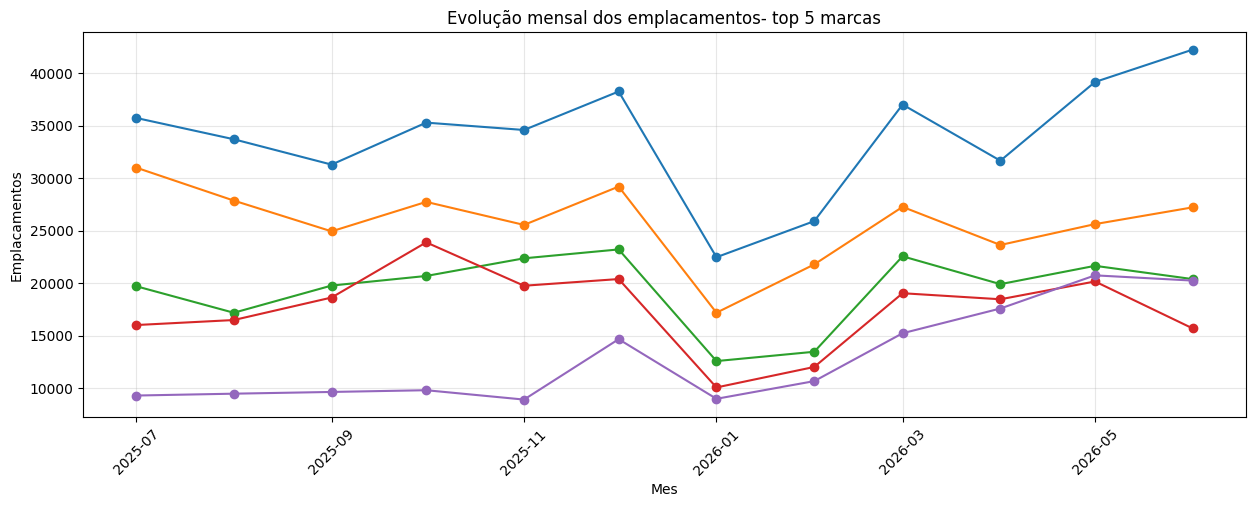

In [32]:
plt.figure(figsize=(15,5))
for marca in top5_marcas:
  dados_marca=evolucao_top5[evolucao_top5['marca']==marca]
  plt.plot(
      dados_marca['data']
      ,dados_marca['emplacamentos']
      ,marker='o'
      ,label=marca
  )
plt.title('Evolução mensal dos emplacamentos- top 5 marcas')
plt.xlabel('Mes')
plt.ylabel('Emplacamentos')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend
plt.show()

In [33]:
total_mensal=(
    dados_automoveis_tratados
    .groupby('data')['emplacamentos']
    .sum()
    .reset_index(name="total_mes")
)
total_mensal


,data,total_mes
0,2025-07-01,172679
1,2025-08-01,163180
2,2025-09-01,168864
3,2025-10-01,181581
4,2025-11-01,171068
5,2025-12-01,196724
6,2026-01-01,114552
7,2026-02-01,130742
8,2026-03-01,190712
9,2026-04-01,173068


In [34]:
marca_mes=marca_mes.merge(total_mensal,on='data')

In [35]:
marca_mes['participacao_top50_pct']=(
    marca_mes['emplacamentos']/marca_mes['total_mes']*100
)
marca_mes['participacao_top50_pct']=(marca_mes['participacao_top50_pct'].round(2))

marca_mes.head(10)


,data,periodo,marca,emplacamentos,total_mes,market_share_pct
0,2025-07-01,2025-07,BMW,542,172679,0.31
1,2025-07-01,2025-07,VW,35728,172679,20.69
2,2025-07-01,2025-07,TOYOTA,11536,172679,6.68
3,2025-07-01,2025-07,RENAULT,6909,172679,4.00
4,2025-07-01,2025-07,PEUGEOT,1809,172679,1.05
5,2025-07-01,2025-07,NISSAN,7271,172679,4.21
6,2025-07-01,2025-07,MITSUBISHI,1096,172679,0.63
7,2025-07-01,2025-07,JEEP,9958,172679,5.77
8,2025-07-01,2025-07,HYUNDAI,16013,172679,9.27
9,2025-07-01,2025-07,OMODA JAECOO,620,172679,0.36


In [36]:
share_top5=marca_mes[marca_mes['marca'].isin(top5_marcas)]


<function matplotlib.pyplot.show(close=None, block=None)>

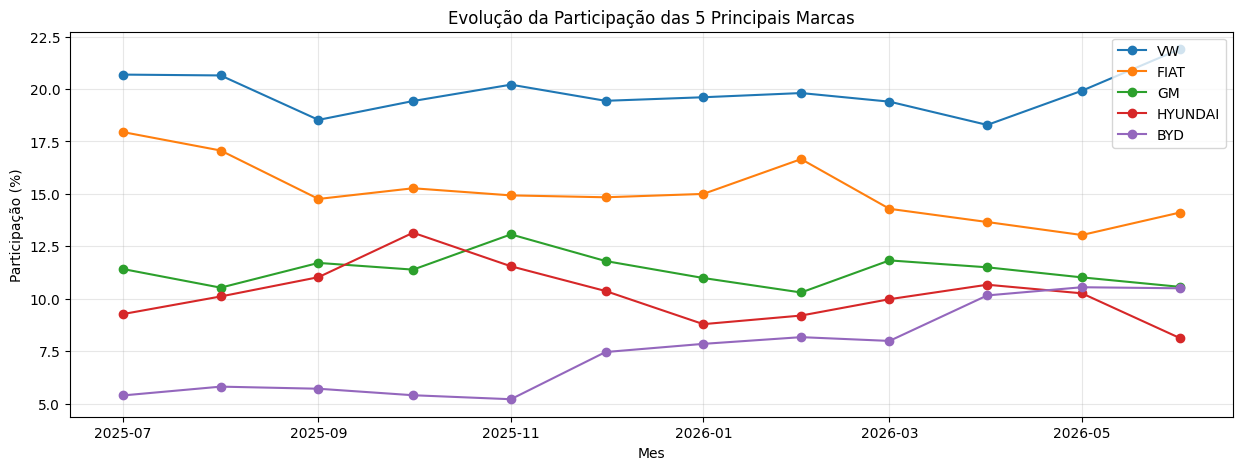

In [37]:
plt.figure(figsize=(15,5))
for marca in top5_marcas:
  dados_marca=share_top5[share_top5['marca']==marca]
  plt.plot(
      dados_marca['data']
      ,dados_marca['participacao_top50_pct']
      ,marker='o'
      ,label=marca
  )
plt.title('Evolução da Participação das 5 Principais Marcas no Top 50')
plt.xlabel('Mes')
plt.ylabel('Participação (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show


In [38]:
share_inicio = (
    marca_mes[
        marca_mes['periodo'] == '2025-07'
    ][['marca', 'participacao_top50_pct']]
    .rename(
        columns={
            'participacao_top50_pct': 'share_inicio'
        }
    )
)


In [39]:
share_final = (
    marca_mes[
        marca_mes['periodo'] == '2026-06'
    ][['marca', 'participacao_top50_pct']]
    .rename(
        columns={
            'participacao_top50_pct': 'share_final'
        }
    )
)


In [40]:
variacao_share = share_inicio.merge(
    share_final,
    on='marca',
    how='outer'
)


In [41]:
variacao_share['variacao_pontos_percentuais'] = (
    variacao_share['share_final']
    - variacao_share['share_inicio']
)

variacao_share.sort_values(
    'variacao_pontos_percentuais',
    ascending=False
)


,marca,share_inicio,share_final,variacao_pontos_percentuais
1,BYD,5.39,10.50,5.11
14,OMODA JAECOO,0.36,2.42,2.06
18,VW,20.69,21.90,1.21
9,HONDA,4.10,5.19,1.09
8,GWM,1.93,2.60,0.67
16,RENAULT,4.00,4.54,0.54
11,JEEP,5.77,5.30,-0.47
2,CAOA CHERY,3.82,3.19,-0.63
7,GM,11.42,10.57,-0.85
3,CITROEN,1.56,0.57,-0.99


In [42]:
maiores_altas = (
    variacao_share
    .dropna()
    .sort_values(
        'variacao_pontos_percentuais',
        ascending=False
    )
    .head(5)
)

maiores_altas


,marca,share_inicio,share_final,variacao_pontos_percentuais
1,BYD,5.39,10.50,5.11
14,OMODA JAECOO,0.36,2.42,2.06
18,VW,20.69,21.90,1.21
9,HONDA,4.10,5.19,1.09
8,GWM,1.93,2.60,0.67


In [43]:
maiores_quedas = (
    variacao_share
    .dropna()
    .sort_values(
        'variacao_pontos_percentuais'
    )
    .head(5)
)

maiores_quedas


,marca,share_inicio,share_final,variacao_pontos_percentuais
4,FIAT,17.95,14.11,-3.84
13,NISSAN,4.21,2.71,-1.50
17,TOYOTA,6.68,5.24,-1.44
10,HYUNDAI,9.27,8.13,-1.14
3,CITROEN,1.56,0.57,-0.99


## 7. Análise por modelo

A análise por modelo busca identificar liderança, consistência, posição média,
crescimento e mudanças na composição do Top 50.


In [44]:
ranking_modelos = (
    dados_automoveis_tratados
    .groupby(['marca', 'modelo'])['emplacamentos']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

ranking_modelos.head(10)

,marca,modelo,emplacamentos
0,VW,POLO,119556
1,FIAT,ARGO,104202
2,VW,T CROSS,96358
3,GM,ONIX,90613
4,HYUNDAI,HB20,87097
5,VW,TERA,86814
6,HYUNDAI,CRETA,80915
7,FIAT,MOBI,73275
8,RENAULT,KWID,63157
9,GM,TRACKER,62857


In [45]:
top10_modelos = ranking_modelos.head(10)

top10_modelos

,marca,modelo,emplacamentos
0,VW,POLO,119556
1,FIAT,ARGO,104202
2,VW,T CROSS,96358
3,GM,ONIX,90613
4,HYUNDAI,HB20,87097
5,VW,TERA,86814
6,HYUNDAI,CRETA,80915
7,FIAT,MOBI,73275
8,RENAULT,KWID,63157
9,GM,TRACKER,62857


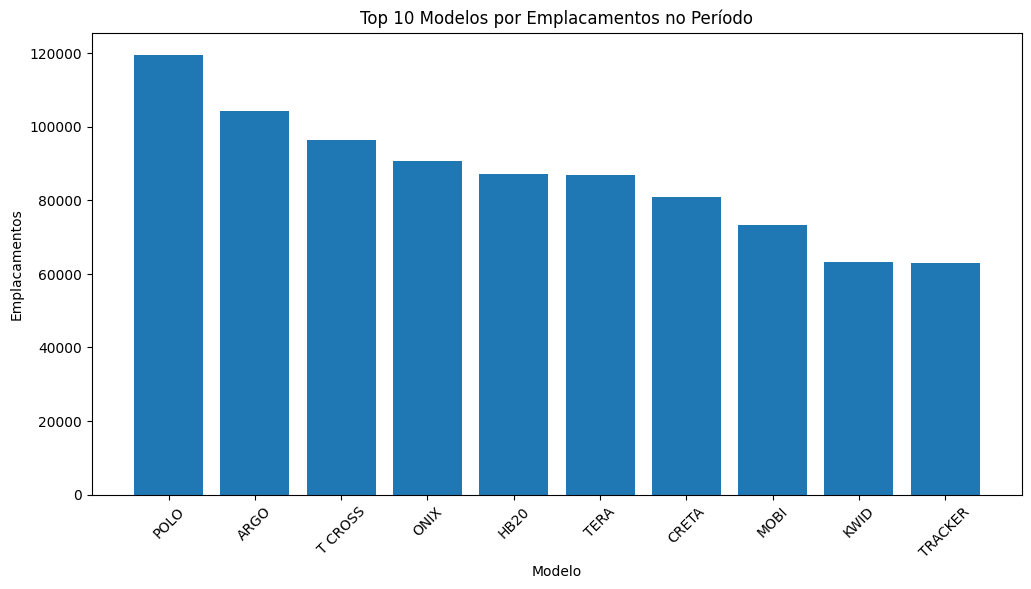

In [46]:
plt.figure(figsize=(12, 6))

plt.bar(
    top10_modelos['modelo'],
    top10_modelos['emplacamentos']
)

plt.title('Top 10 Modelos por Emplacamentos no Período')
plt.xlabel('Modelo')
plt.ylabel('Emplacamentos')

plt.xticks(rotation=45)

plt.show()

In [47]:
media_modelos = (
    dados_automoveis_tratados
    .groupby(['marca', 'modelo'])['emplacamentos']
    .mean()
    .sort_values(ascending=False)
    .reset_index(name='media_mensal')
)

media_modelos.head(10)

,marca,modelo,media_mensal
0,VW,POLO,9963.000000
1,FIAT,ARGO,8683.500000
2,VW,T CROSS,8029.833333
3,GM,ONIX,7551.083333
4,HYUNDAI,HB20,7258.083333
5,VW,TERA,7234.500000
6,HYUNDAI,CRETA,6742.916667
7,FIAT,MOBI,6106.250000
8,RENAULT,KWID,5263.083333
9,GM,TRACKER,5238.083333


In [48]:
lideres_mensais = dados_automoveis_tratados[
    dados_automoveis_tratados['posicao'] == 1
]

lideres_mensais[
    ['periodo', 'marca', 'modelo', 'emplacamentos']
]

,periodo,marca,modelo,emplacamentos
0,2025-07,VW,POLO,12940
50,2025-08,VW,POLO,12908
100,2025-09,VW,POLO,10647
150,2025-10,VW,TERA,10162
200,2025-11,VW,TERA,9772
250,2025-12,VW,T CROSS,10721
300,2026-01,VW,T CROSS,5741
350,2026-02,VW,POLO,7517
400,2026-03,VW,POLO,11051
450,2026-04,VW,POLO,8367


In [49]:
vezes_primeiro = (
    lideres_mensais
    .groupby(['marca', 'modelo'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='vezes_em_primeiro')
)

vezes_primeiro

,marca,modelo,vezes_em_primeiro
0,VW,POLO,7
1,VW,T CROSS,3
2,VW,TERA,2


In [50]:
top5_mensal = dados_automoveis_tratados[
    dados_automoveis_tratados['posicao'] <= 5
]

presenca_top5 = (
    top5_mensal
    .groupby(['marca', 'modelo'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='meses_no_top5')
)

presenca_top5.head(10)

,marca,modelo,meses_no_top5
0,FIAT,ARGO,12
1,VW,POLO,12
2,VW,T CROSS,9
3,GM,ONIX,7
4,VW,TERA,7
5,HYUNDAI,HB20,6
6,HYUNDAI,CRETA,3
7,FIAT,MOBI,2
8,TOYOTA,COROLLA CROSS,2


In [51]:
top10_mensal = dados_automoveis_tratados[
    dados_automoveis_tratados['posicao'] <= 10
]

presenca_top10 = (
    top10_mensal
    .groupby(['marca', 'modelo'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='meses_no_top10')
)

presenca_top10.head(10)

,marca,modelo,meses_no_top10
0,FIAT,ARGO,12
1,VW,POLO,12
2,HYUNDAI,CRETA,12
3,GM,ONIX,12
4,VW,T CROSS,11
5,HYUNDAI,HB20,11
6,VW,TERA,10
7,RENAULT,KWID,6
8,FIAT,MOBI,6
9,BYD,DOLPHIN MINI,5


In [52]:
posicao_media = (
    dados_automoveis_tratados
    .groupby(['marca', 'modelo'])['posicao']
    .mean()
    .sort_values()
    .reset_index(name='posicao_media')
)

posicao_media.head(10)

,marca,modelo,posicao_media
0,VW,POLO,1.750000
1,FIAT,ARGO,2.916667
2,VW,T CROSS,4.500000
3,GM,ONIX,4.916667
4,HYUNDAI,HB20,6.083333
5,VW,TERA,6.666667
6,HYUNDAI,CRETA,7.083333
7,FIAT,MOBI,9.166667
8,GM,TRACKER,11.833333
9,RENAULT,KWID,12.000000


In [53]:
ranking_modelos_completo = (
    ranking_modelos
    .merge(
        media_modelos,
        on=['marca', 'modelo']
    )
    .merge(
        posicao_media,
        on=['marca', 'modelo']
    )
)

ranking_modelos_completo.head(10)

,marca,modelo,emplacamentos,media_mensal,posicao_media
0,VW,POLO,119556,9963.000000,1.750000
1,FIAT,ARGO,104202,8683.500000,2.916667
2,VW,T CROSS,96358,8029.833333,4.500000
3,GM,ONIX,90613,7551.083333,4.916667
4,HYUNDAI,HB20,87097,7258.083333,6.083333
5,VW,TERA,86814,7234.500000,6.666667
6,HYUNDAI,CRETA,80915,6742.916667,7.083333
7,FIAT,MOBI,73275,6106.250000,9.166667
8,RENAULT,KWID,63157,5263.083333,12.000000
9,GM,TRACKER,62857,5238.083333,11.833333


In [54]:
ranking_modelos_completo = (
    ranking_modelos_completo
    .merge(
        presenca_top10,
        on=['marca', 'modelo'],
        how='left'
    )
)

ranking_modelos_completo['meses_no_top10'] = (
    ranking_modelos_completo['meses_no_top10']
    .fillna(0)
)

ranking_modelos_completo.head(10)

,marca,modelo,emplacamentos,media_mensal,posicao_media,meses_no_top10
0,VW,POLO,119556,9963.000000,1.750000,12.0
1,FIAT,ARGO,104202,8683.500000,2.916667,12.0
2,VW,T CROSS,96358,8029.833333,4.500000,11.0
3,GM,ONIX,90613,7551.083333,4.916667,12.0
4,HYUNDAI,HB20,87097,7258.083333,6.083333,11.0
5,VW,TERA,86814,7234.500000,6.666667,10.0
6,HYUNDAI,CRETA,80915,6742.916667,7.083333,12.0
7,FIAT,MOBI,73275,6106.250000,9.166667,6.0
8,RENAULT,KWID,63157,5263.083333,12.000000,6.0
9,GM,TRACKER,62857,5238.083333,11.833333,3.0


In [55]:
polo = dados_automoveis_tratados[
    (dados_automoveis_tratados['marca'] == 'VW') &
    (dados_automoveis_tratados['modelo'] == 'POLO')
]

polo[
    ['periodo', 'posicao', 'emplacamentos']
]

,periodo,posicao,emplacamentos
0,2025-07,1,12940
50,2025-08,1,12908
100,2025-09,1,10647
153,2025-10,4,9150
202,2025-11,3,9381
252,2025-12,3,10434
301,2026-01,2,5699
350,2026-02,1,7517
400,2026-03,1,11051
450,2026-04,1,8367


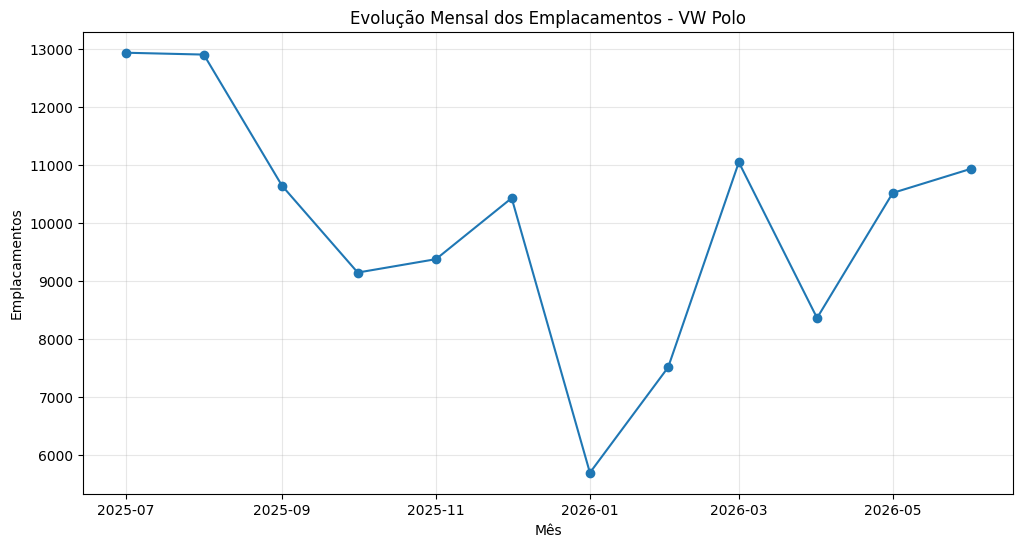

In [56]:
plt.figure(figsize=(12, 6))

plt.plot(
    polo['data'],
    polo['emplacamentos'],
    marker='o'
)

plt.title('Evolução Mensal dos Emplacamentos - VW Polo')
plt.xlabel('Mês')
plt.ylabel('Emplacamentos')

plt.grid(alpha=0.3)

plt.show()

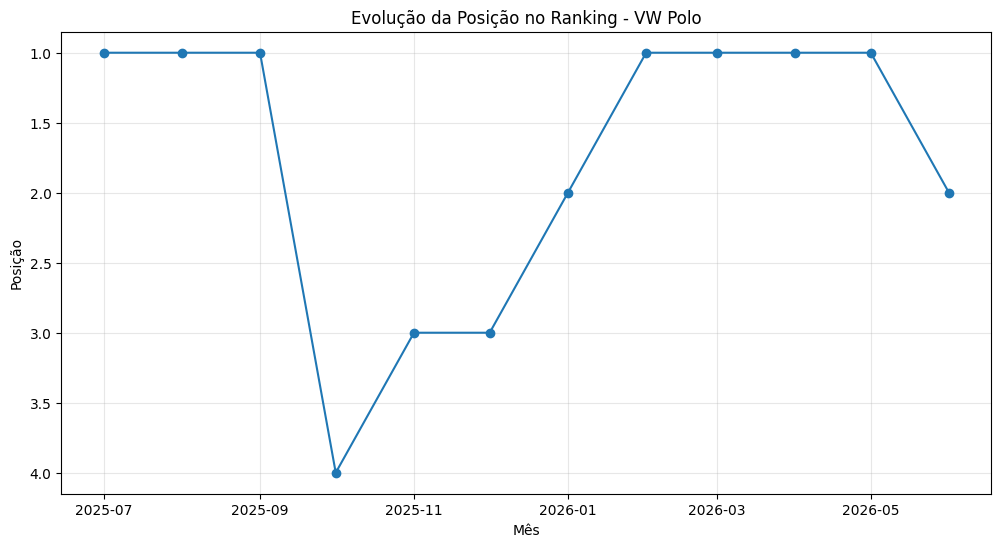

In [57]:
plt.figure(figsize=(12, 6))

plt.plot(
    polo['data'],
    polo['posicao'],
    marker='o'
)

plt.gca().invert_yaxis()

plt.title('Evolução da Posição no Ranking - VW Polo')
plt.xlabel('Mês')
plt.ylabel('Posição')

plt.grid(alpha=0.3)

plt.show()

In [58]:
modelos_comparacao = [
    'POLO',
    'ARGO',
    'T CROSS',
    'COROLLA CROSS'
]

In [59]:
dados_comparacao = dados_automoveis_tratados[
    dados_automoveis_tratados['modelo'].isin(modelos_comparacao)
]

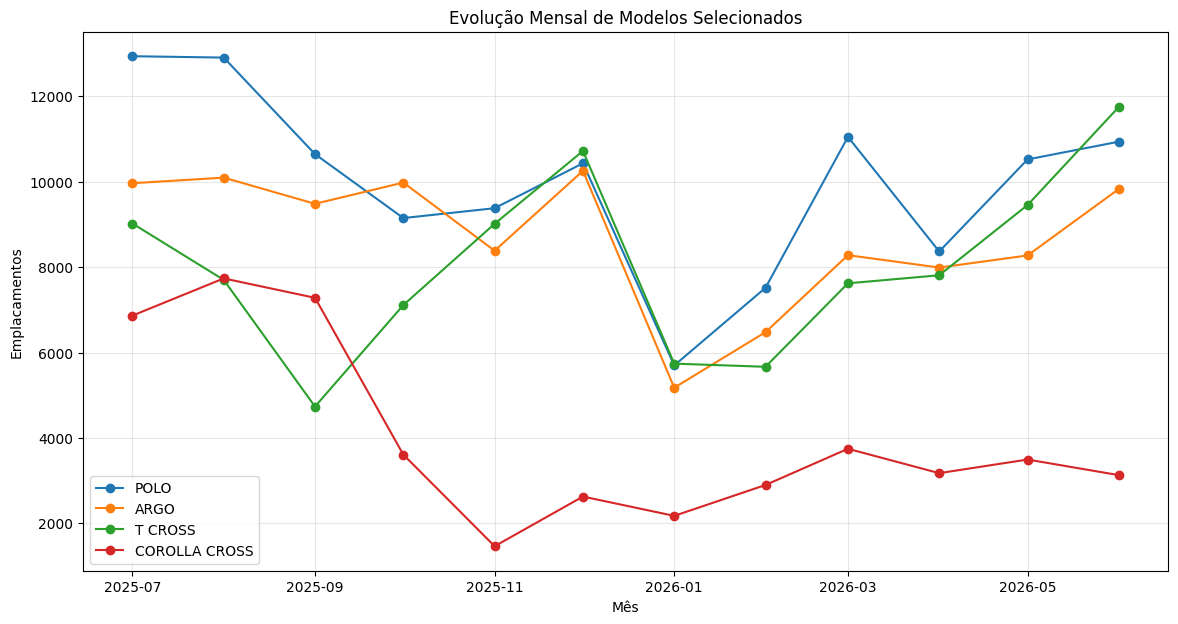

In [60]:
plt.figure(figsize=(14, 7))

for modelo in modelos_comparacao:

    dados_modelo = dados_comparacao[
        dados_comparacao['modelo'] == modelo
    ]

    plt.plot(
        dados_modelo['data'],
        dados_modelo['emplacamentos'],
        marker='o',
        label=modelo
    )

plt.title('Evolução Mensal de Modelos Selecionados')
plt.xlabel('Mês')
plt.ylabel('Emplacamentos')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [61]:
inicio_modelos = (
    dados_automoveis_tratados[
        dados_automoveis_tratados['periodo'] == '2025-07'
    ][['marca', 'modelo', 'emplacamentos']]
    .rename(
        columns={
            'emplacamentos': 'emplacamentos_inicio'
        }
    )
)

In [62]:
fim_modelos = (
    dados_automoveis_tratados[
        dados_automoveis_tratados['periodo'] == '2026-06'
    ][['marca', 'modelo', 'emplacamentos']]
    .rename(
        columns={
            'emplacamentos': 'emplacamentos_fim'
        }
    )
)

In [63]:
crescimento_modelos = inicio_modelos.merge(
    fim_modelos,
    on=['marca', 'modelo'],
    how='inner'
)

In [64]:
crescimento_modelos['variacao_absoluta'] = (
    crescimento_modelos['emplacamentos_fim']
    - crescimento_modelos['emplacamentos_inicio']
)

In [65]:
crescimento_modelos['variacao_pct'] = (
    (
        crescimento_modelos['emplacamentos_fim']
        - crescimento_modelos['emplacamentos_inicio']
    )
    / crescimento_modelos['emplacamentos_inicio']
) * 100

In [66]:
crescimento_modelos['variacao_pct'] = (
    crescimento_modelos['variacao_pct']
    .round(2)
)

In [67]:
crescimento_modelos.sort_values(
    'variacao_pct',
    ascending=False
).head(10)

,marca,modelo,emplacamentos_inicio,emplacamentos_fim,variacao_absoluta,variacao_pct
39,OMODA JAECOO,JAECOO 7,620,2731,2111,340.48
35,BYD,DOLPHIN,1305,5512,4207,322.38
20,VW,TERA,3244,9289,6045,186.34
31,CAOA CHERY,TIGGO 5X,1434,3831,2397,167.15
24,BYD,DOLPHIN MINI,3011,6457,3446,114.45
22,BYD,SONG,3164,6632,3468,109.61
37,BYD,KING,964,1643,679,70.44
38,VW,TAOS,882,1485,603,68.37
27,FIAT,CRONOS,1894,2686,792,41.82
2,VW,T CROSS,9022,11753,2731,30.27


In [68]:
crescimento_modelos.sort_values(
    'variacao_pct'
).head(10)

,marca,modelo,emplacamentos_inicio,emplacamentos_fim,variacao_absoluta,variacao_pct
8,NISSAN,KICKS,6341,2294,-4047,-63.82
7,TOYOTA,COROLLA CROSS,6866,3130,-3736,-54.41
21,TOYOTA,COROLLA,3170,1947,-1223,-38.58
17,CAOA CHERY,TIGGO 7,3721,2330,-1391,-37.38
3,FIAT,MOBI,8099,5073,-3026,-37.36
6,GM,TRACKER,6974,4490,-2484,-35.62
9,FIAT,FASTBACK,6207,4278,-1929,-31.08
4,HYUNDAI,CRETA,7856,5533,-2323,-29.57
28,RENAULT,DUSTER,1851,1370,-481,-25.99
30,TOYOTA,HILUX SW4,1500,1125,-375,-25.00


In [70]:
modelos_inicio = set(
    dados_automoveis_tratados[
        dados_automoveis_tratados['periodo'] == '2025-07'
    ]['modelo']
)

In [71]:
modelos_fim = set(
    dados_automoveis_tratados[
        dados_automoveis_tratados['periodo'] == '2026-06'
    ]['modelo']
)

In [72]:
novos_modelos = modelos_fim - modelos_inicio

novos_modelos

{'BOREAL',
 'EX2',
 'EX5',
 'HAVAL H9',
 'KAIT',
 'OMODA 5',
 'SONIC',
 'TIGUAN',
 'WR-V',
 'YARIS CROSS'}

In [73]:
modelos_que_sairam = modelos_inicio - modelos_fim

modelos_que_sairam

{'2008',
 '208',
 'BASALT',
 'BRONCO',
 'ECLIPSE CROSS',
 'TERRITORY',
 'TIGGO 8',
 'VERSA',
 'X1',
 'YUAN'}

## 8. Mercado de veículos eletrificados

Nesta etapa é utilizada a base agregada de híbridos e elétricos para avaliar a
evolução do volume e da participação dos eletrificados no mercado de
automóveis.


In [74]:
dados_eletrificados_tratados.head()

,periodo,ano,mes_numero,mes,total_automoveis,hibridos,eletricos,total_eletrificados,participacao_hibridos_pct,participacao_eletricos_pct,participacao_eletrificados_pct,data
0,2025-07,2025,7,Julho,181787,18015,6953,24968,9.91,3.82,13.73,2025-07-01
1,2025-08,2025,8,Agosto,172280,17533,7594,25127,10.18,4.41,14.58,2025-08-01
2,2025-09,2025,9,Setembro,178548,18955,8023,26978,10.62,4.49,15.11,2025-09-01
3,2025-10,2025,10,Outubro,192752,19702,7826,27528,10.22,4.06,14.28,2025-10-01
4,2025-11,2025,11,Novembro,182044,18609,7202,25811,10.22,3.96,14.18,2025-11-01


In [75]:
dados_eletrificados_tratados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   periodo                         12 non-null     object        
 1   ano                             12 non-null     int64         
 2   mes_numero                      12 non-null     int64         
 3   mes                             12 non-null     object        
 4   total_automoveis                12 non-null     int64         
 5   hibridos                        12 non-null     int64         
 6   eletricos                       12 non-null     int64         
 7   total_eletrificados             12 non-null     int64         
 8   participacao_hibridos_pct       12 non-null     float64       
 9   participacao_eletricos_pct      12 non-null     float64       
 10  participacao_eletrificados_pct  12 non-null     float64       
 11  data    

In [76]:
dados_eletrificados_tratados[
    [
        'periodo',
        'total_automoveis',
        'hibridos',
        'eletricos',
        'total_eletrificados'
    ]
]

,periodo,total_automoveis,hibridos,eletricos,total_eletrificados
0,2025-07,181787,18015,6953,24968
1,2025-08,172280,17533,7594,25127
2,2025-09,178548,18955,8023,26978
3,2025-10,192752,19702,7826,27528
4,2025-11,182044,18609,7202,25811
5,2025-12,210732,27823,11456,39279
6,2026-01,125136,18995,8198,27193
7,2026-02,140548,19250,8654,27904
8,2026-03,206375,25630,13991,39621
9,2026-04,187313,25767,17468,43235


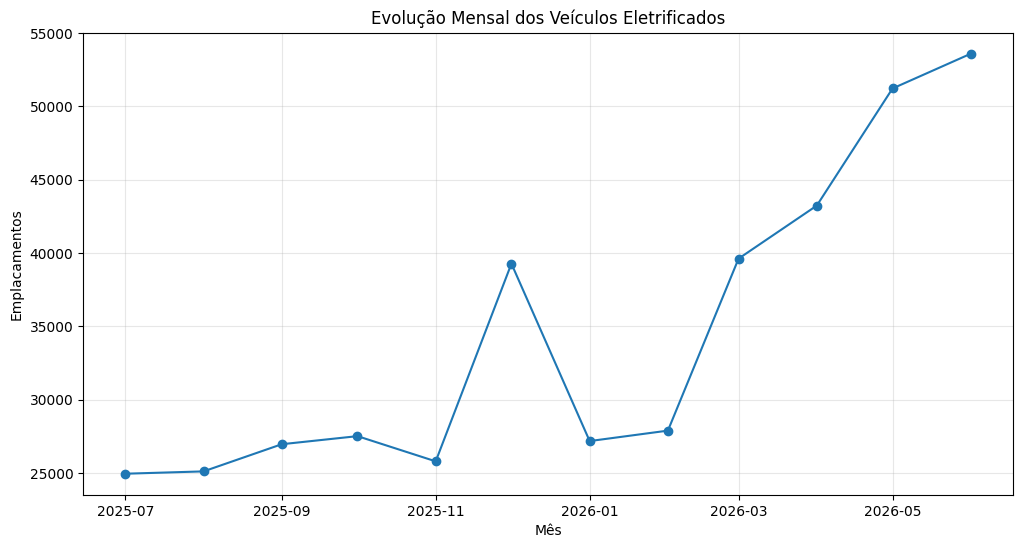

In [77]:
plt.figure(figsize=(12, 6))

plt.plot(
    dados_eletrificados_tratados['data'],
   dados_eletrificados_tratados['total_eletrificados'],
    marker='o'
)

plt.title('Evolução Mensal dos Veículos Eletrificados')
plt.xlabel('Mês')
plt.ylabel('Emplacamentos')

plt.grid(alpha=0.3)

plt.show()

In [78]:
inicio = dados_eletrificados_tratados.iloc[0]['total_eletrificados']
fim = dados_eletrificados_tratados.iloc[-1]['total_eletrificados']

crescimento_eletrificados = (
    (fim - inicio) / inicio
) * 100

print(
    f'Crescimento dos eletrificados no período: '
    f'{crescimento_eletrificados:.2f}%'
)

Crescimento dos eletrificados no período: 114.60%


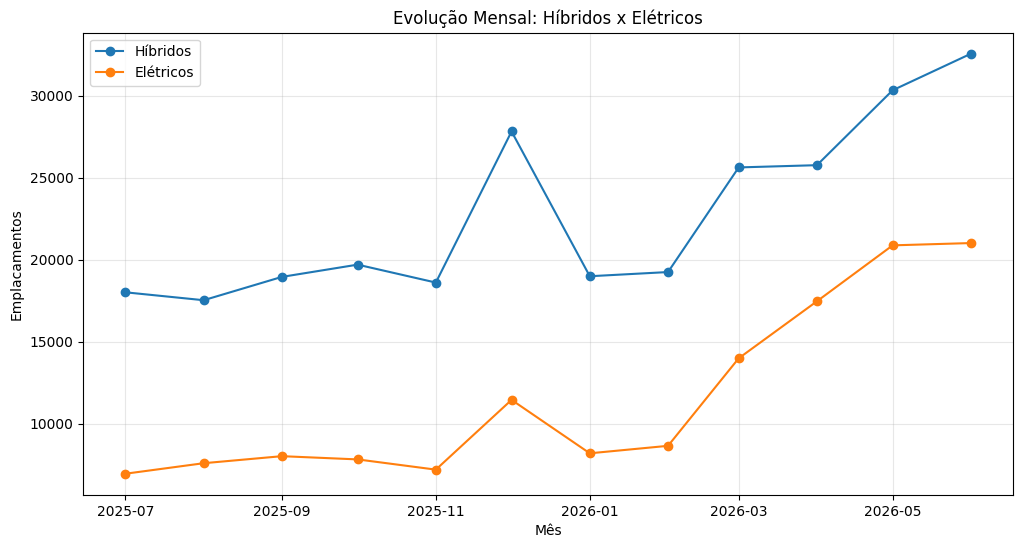

In [79]:
plt.figure(figsize=(12, 6))

plt.plot(
    dados_eletrificados_tratados['data'],
    dados_eletrificados_tratados['hibridos'],
    marker='o',
    label='Híbridos'
)

plt.plot(
    dados_eletrificados_tratados['data'],
    dados_eletrificados_tratados['eletricos'],
    marker='o',
    label='Elétricos'
)

plt.title('Evolução Mensal: Híbridos x Elétricos')
plt.xlabel('Mês')
plt.ylabel('Emplacamentos')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [80]:
crescimento_hibridos = (
    (
        dados_eletrificados_tratados.iloc[-1]['hibridos']
        - dados_eletrificados_tratados.iloc[0]['hibridos']
    )
    / dados_eletrificados_tratados.iloc[0]['hibridos']
) * 100

crescimento_hibridos

np.float64(80.7549264501804)

In [81]:
crescimento_eletricos = (
    (
        dados_eletrificados_tratados.iloc[-1]['eletricos']
        - dados_eletrificados_tratados.iloc[0]['eletricos']
    )
    / dados_eletrificados_tratados.iloc[0]['eletricos']
) * 100

crescimento_eletricos

np.float64(202.28678268373366)

In [82]:
print(f'Crescimento dos híbridos: {crescimento_hibridos:.2f}%')
print(f'Crescimento dos elétricos: {crescimento_eletricos:.2f}%')

Crescimento dos híbridos: 80.75%
Crescimento dos elétricos: 202.29%


In [83]:
dados_eletrificados_tratados[
    [
        'periodo',
        'participacao_eletrificados_pct'
    ]
]

,periodo,participacao_eletrificados_pct
0,2025-07,13.73
1,2025-08,14.58
2,2025-09,15.11
3,2025-10,14.28
4,2025-11,14.18
5,2025-12,18.64
6,2026-01,21.73
7,2026-02,19.85
8,2026-03,19.20
9,2026-04,23.08


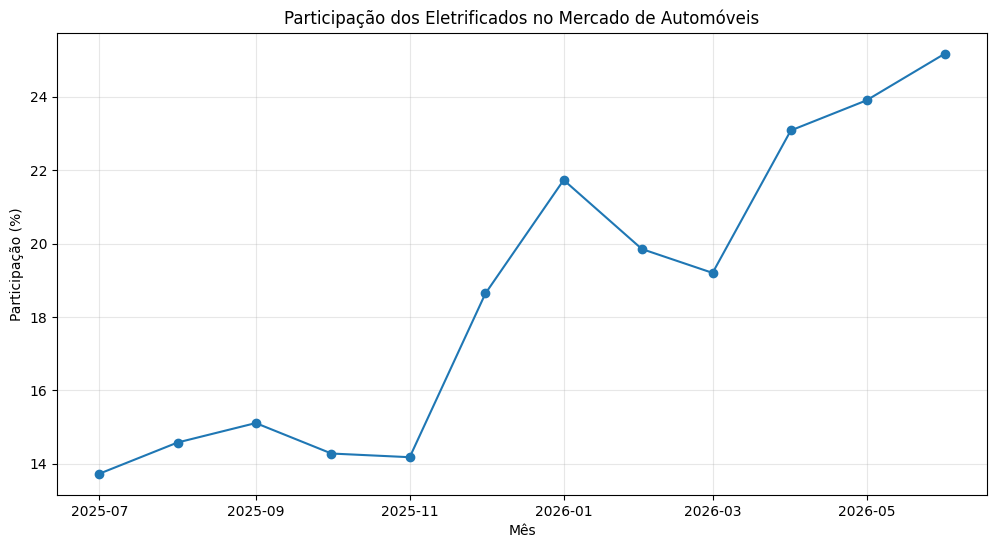

In [84]:
plt.figure(figsize=(12, 6))

plt.plot(
   dados_eletrificados_tratados['data'],
    dados_eletrificados_tratados['participacao_eletrificados_pct'],
    marker='o'
)

plt.title('Participação dos Eletrificados no Mercado de Automóveis')
plt.xlabel('Mês')
plt.ylabel('Participação (%)')

plt.grid(alpha=0.3)

plt.show()

In [85]:
share_inicio = (
    dados_eletrificados_tratados
    .iloc[0]['participacao_eletrificados_pct']
)

share_final = (
    dados_eletrificados_tratados
    .iloc[-1]['participacao_eletrificados_pct']
)

ganho_share = share_final - share_inicio

print(f'Participação inicial: {share_inicio:.2f}%')
print(f'Participação final: {share_final:.2f}%')
print(f'Ganho de participação: {ganho_share:.2f} p.p.')

Participação inicial: 13.73%
Participação final: 25.17%
Ganho de participação: 11.44 p.p.


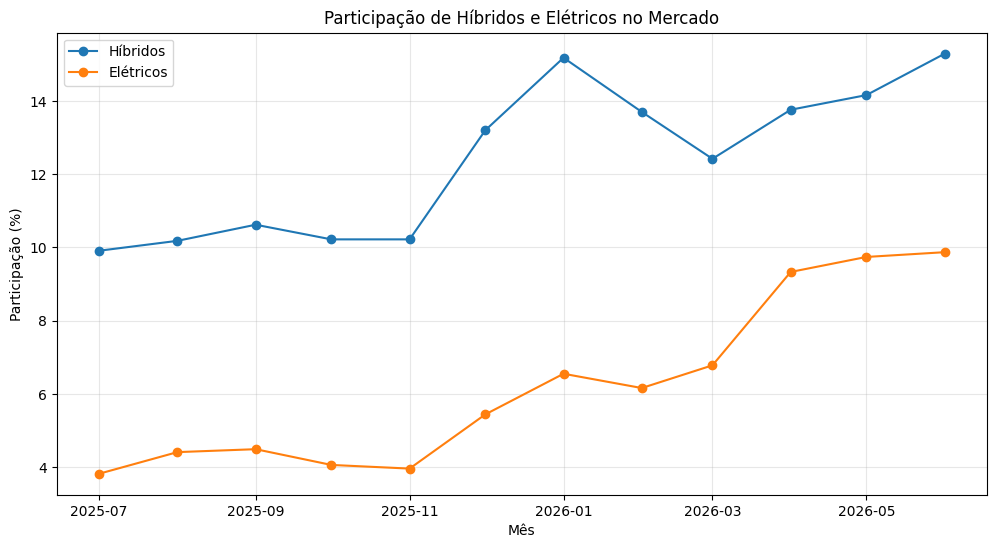

In [86]:
plt.figure(figsize=(12, 6))

plt.plot(
    dados_eletrificados_tratados['data'],
   dados_eletrificados_tratados['participacao_hibridos_pct'],
    marker='o',
    label='Híbridos'
)

plt.plot(
dados_eletrificados_tratados['data'],
    dados_eletrificados_tratados['participacao_eletricos_pct'],
    marker='o',
    label='Elétricos'
)

plt.title('Participação de Híbridos e Elétricos no Mercado')
plt.xlabel('Mês')
plt.ylabel('Participação (%)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [87]:
dados_eletrificados_tratados['crescimento_eletrificados_pct'] = (
    dados_eletrificados_tratados['total_eletrificados']
    .pct_change() * 100
)

dados_eletrificados_tratados['crescimento_eletricos_pct'] = (
    dados_eletrificados_tratados['eletricos']
    .pct_change() * 100
)

dados_eletrificados_tratados['crescimento_hibridos_pct'] = (
    dados_eletrificados_tratados['hibridos']
    .pct_change() * 100
)

In [89]:
colunas_crescimento = [
    'crescimento_eletrificados_pct',
    'crescimento_eletricos_pct',
    'crescimento_hibridos_pct'
]

dados_eletrificados_tratados[colunas_crescimento] = (
   dados_eletrificados_tratados[colunas_crescimento]
    .round(2)
)

In [90]:
dados_eletrificados_tratados[
    [
        'periodo',
        'total_eletrificados',
        'crescimento_eletrificados_pct'
    ]
]

,periodo,total_eletrificados,crescimento_eletrificados_pct
0,2025-07,24968,NaN
1,2025-08,25127,0.64
2,2025-09,26978,7.37
3,2025-10,27528,2.04
4,2025-11,25811,-6.24
5,2025-12,39279,52.18
6,2026-01,27193,-30.77
7,2026-02,27904,2.61
8,2026-03,39621,41.99
9,2026-04,43235,9.12


In [91]:
maior_share = dados_eletrificados_tratados.loc[
    dados_eletrificados_tratados[
        'participacao_eletrificados_pct'
    ].idxmax()
]

maior_share[
    [
        'periodo',
        'participacao_eletrificados_pct'
    ]
]

,11
periodo,2026-06
participacao_eletrificados_pct,25.17


In [92]:
menor_share = dados_eletrificados_tratados.loc[
    dados_eletrificados_tratados[
        'participacao_eletrificados_pct'
    ].idxmin()
]

menor_share[
    [
        'periodo',
        'participacao_eletrificados_pct'
    ]
]

,0
periodo,2025-07
participacao_eletrificados_pct,13.73


In [93]:
dados_eletrificados_tratados['share_hibridos_eletrificados'] = (
    dados_eletrificados_tratados['hibridos']
    / dados_eletrificados_tratados['total_eletrificados']
    * 100
)

dados_eletrificados_tratados['share_eletricos_eletrificados'] = (
    dados_eletrificados_tratados['eletricos']
    / dados_eletrificados_tratados['total_eletrificados']
    * 100
)

In [94]:
dados_eletrificados_tratados[
    [
        'periodo',
        'share_hibridos_eletrificados',
        'share_eletricos_eletrificados'
    ]
]

,periodo,share_hibridos_eletrificados,share_eletricos_eletrificados
0,2025-07,72.152355,27.847645
1,2025-08,69.777530,30.222470
2,2025-09,70.260953,29.739047
3,2025-10,71.570764,28.429236
4,2025-11,72.097168,27.902832
5,2025-12,70.834288,29.165712
6,2026-01,69.852536,30.147464
7,2026-02,68.986525,31.013475
8,2026-03,64.687918,35.312082
9,2026-04,59.597548,40.402452


In [98]:
dados_eletrificados_tratados['indice_mercado'] = (
    dados_eletrificados_tratados['total_automoveis']
    / dados_eletrificados_tratados.iloc[0]['total_automoveis']
    * 100
)

dados_eletrificados_tratados['indice_eletrificados'] = (
    dados_eletrificados_tratados['total_eletrificados']
    / dados_eletrificados_tratados.iloc[0]['total_eletrificados']
    * 100
)

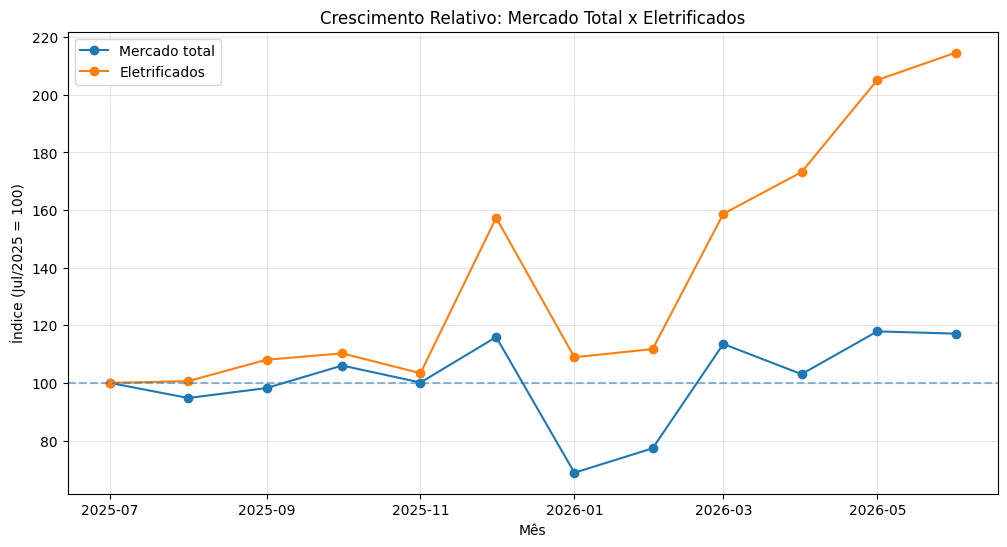

In [99]:
plt.figure(figsize=(12, 6))

plt.plot(
    dados_eletrificados_tratados['data'],
    dados_eletrificados_tratados['indice_mercado'],
    marker='o',
    label='Mercado total'
)

plt.plot(
    dados_eletrificados_tratados['data'],
    dados_eletrificados_tratados['indice_eletrificados'],
    marker='o',
    label='Eletrificados'
)

plt.axhline(
    y=100,
    linestyle='--',
    alpha=0.5
)

plt.title('Crescimento Relativo: Mercado Total x Eletrificados')
plt.xlabel('Mês')
plt.ylabel('Índice (Jul/2025 = 100)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 9. Aceleração e desaceleração da eletrificação

Além do crescimento acumulado, analisamos a mudança mensal da participação para
identificar períodos de avanço e retração.


In [102]:
evolucao_eletrificados = dados_eletrificados_tratados[
    [
        'periodo',
        'hibridos',
        'eletricos',
        'total_eletrificados',
        'participacao_eletrificados_pct'
    ]
].copy()

evolucao_eletrificados

,periodo,hibridos,eletricos,total_eletrificados,participacao_eletrificados_pct
0,2025-07,18015,6953,24968,13.73
1,2025-08,17533,7594,25127,14.58
2,2025-09,18955,8023,26978,15.11
3,2025-10,19702,7826,27528,14.28
4,2025-11,18609,7202,25811,14.18
5,2025-12,27823,11456,39279,18.64
6,2026-01,18995,8198,27193,21.73
7,2026-02,19250,8654,27904,19.85
8,2026-03,25630,13991,39621,19.20
9,2026-04,25767,17468,43235,23.08


In [103]:
evolucao_eletrificados['variacao_share_pp'] = (
    evolucao_eletrificados[
        'participacao_eletrificados_pct'
    ].diff()
)

evolucao_eletrificados[
    [
        'periodo',
        'participacao_eletrificados_pct',
        'variacao_share_pp'
    ]
]

,periodo,participacao_eletrificados_pct,variacao_share_pp
0,2025-07,13.73,NaN
1,2025-08,14.58,0.85
2,2025-09,15.11,0.53
3,2025-10,14.28,-0.83
4,2025-11,14.18,-0.10
5,2025-12,18.64,4.46
6,2026-01,21.73,3.09
7,2026-02,19.85,-1.88
8,2026-03,19.20,-0.65
9,2026-04,23.08,3.88


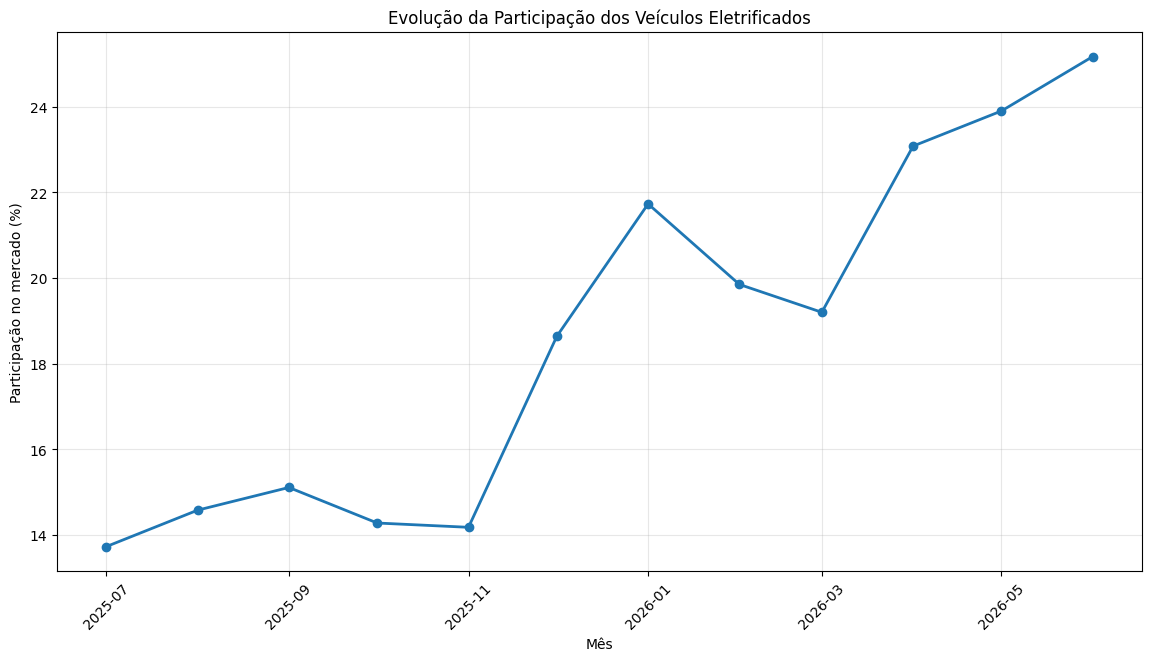

In [104]:
plt.figure(figsize=(14, 7))

plt.plot(
    dados_eletrificados_tratados['data'],
    dados_eletrificados_tratados['participacao_eletrificados_pct'],
    marker='o',
    linewidth=2
)

plt.title(
    'Evolução da Participação dos Veículos Eletrificados'
)
plt.xlabel('Mês')
plt.ylabel('Participação no mercado (%)')

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

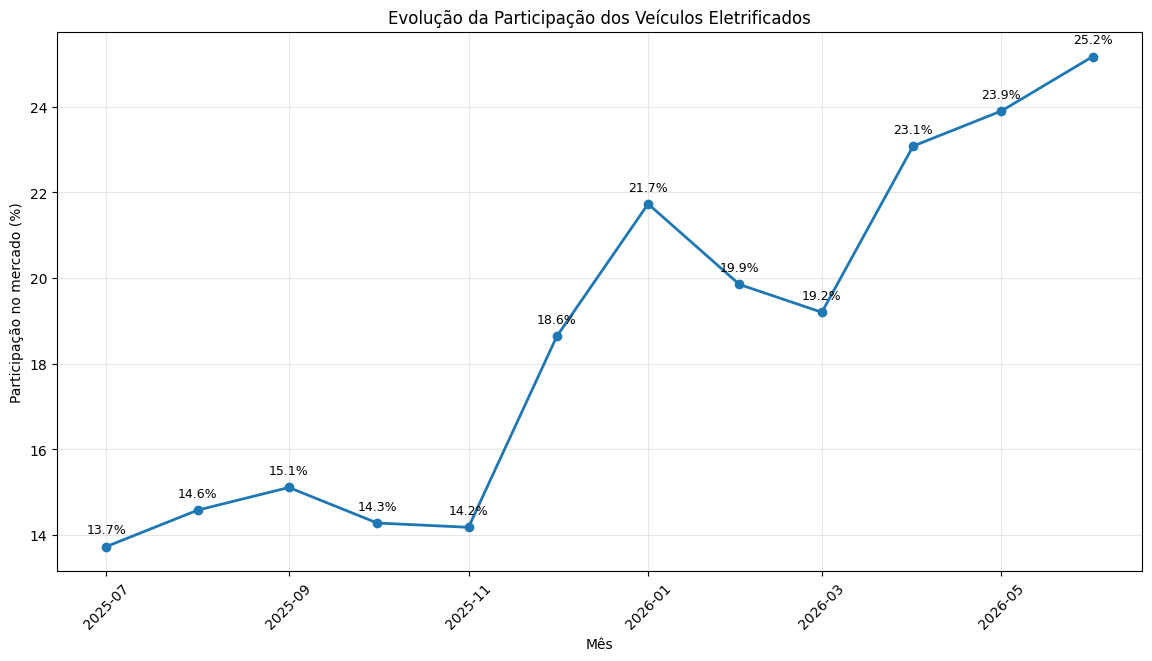

In [105]:
plt.figure(figsize=(14, 7))

plt.plot(
    dados_eletrificados_tratados['data'],
    dados_eletrificados_tratados['participacao_eletrificados_pct'],
    marker='o',
    linewidth=2
)

for x, y in zip(
    dados_eletrificados_tratados['data'],
    dados_eletrificados_tratados['participacao_eletrificados_pct']
):
    plt.text(
        x,
        y + 0.3,
        f'{y:.1f}%',
        ha='center',
        fontsize=9
    )

plt.title(
    'Evolução da Participação dos Veículos Eletrificados'
)
plt.xlabel('Mês')
plt.ylabel('Participação no mercado (%)')

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

In [106]:
maiores_avancos = (
    evolucao_eletrificados
    .sort_values(
        'variacao_share_pp',
        ascending=False
    )
    .head(3)
)

maiores_avancos[
    [
        'periodo',
        'participacao_eletrificados_pct',
        'variacao_share_pp'
    ]
]

,periodo,participacao_eletrificados_pct,variacao_share_pp
5,2025-12,18.64,4.46
9,2026-04,23.08,3.88
6,2026-01,21.73,3.09


In [107]:
maiores_quedas = (
    evolucao_eletrificados
    .dropna()
    .sort_values(
        'variacao_share_pp'
    )
    .head(3)
)

maiores_quedas[
    [
        'periodo',
        'participacao_eletrificados_pct',
        'variacao_share_pp'
    ]
]

,periodo,participacao_eletrificados_pct,variacao_share_pp
7,2026-02,19.85,-1.88
3,2025-10,14.28,-0.83
8,2026-03,19.20,-0.65


## 10. Principais conclusões

Entre julho de 2025 e junho de 2026, os veículos eletrificados apresentaram
forte expansão:

- **Eletrificados:** +114,60%
- **Híbridos:** +80,75%
- **100% elétricos:** +202,29%
- **Participação dos eletrificados:** de 13,73% para 25,17%
- **Ganho de participação:** +11,44 pontos percentuais

O avanço não foi linear. Houve retrações em alguns meses, mas a série terminou
no maior nível de participação observado. O maior ganho mensal ocorreu em
dezembro de 2025 (+4,46 p.p.), seguido por abril de 2026 (+3,88 p.p.) e janeiro
de 2026 (+3,09 p.p.).

Os resultados indicam que os eletrificados não apenas cresceram em volume:
eles também conquistaram uma parcela maior do mercado de automóveis no período,
com destaque para o ritmo de crescimento dos veículos 100% elétricos.

### Limitações

- A análise de marcas e modelos utiliza somente os modelos presentes no Top 50
  mensal.
- Um modelo fora do Top 50 em determinado mês não possui observação nessa base.
- Comparações de crescimento entre julho/2025 e junho/2026 consideram apenas
  modelos presentes nos dois meses quando utilizado `merge(..., how='inner')`.
- A análise de eletrificação é agregada e não permite identificar, nesta base,
  quais fabricantes ou modelos eletrificados explicam o crescimento.
